<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


 ## Lab 2: Data wrangling 


Estimated time needed: **60** minutes


In this lab, we will perform some Exploratory Data Analysis (EDA) to find some patterns in the data and determine what would be the label for training supervised models. 

In the data set, there are several different cases where the booster did not land successfully. Sometimes a landing was attempted but failed due to an accident; for example, <code>True Ocean</code> means the mission outcome was successfully  landed to a specific region of the ocean while <code>False Ocean</code> means the mission outcome was unsuccessfully landed to a specific region of the ocean. <code>True RTLS</code> means the mission outcome was successfully  landed to a ground pad <code>False RTLS</code> means the mission outcome was unsuccessfully landed to a ground pad.<code>True ASDS</code> means the mission outcome was successfully landed on  a drone ship <code>False ASDS</code> means the mission outcome was unsuccessfully landed on a drone ship. 

In this lab we will mainly convert those outcomes into Training Labels with `1` means the booster successfully landed `0` means it was unsuccessful.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


## Objectives
Perform exploratory  Data Analysis and determine Training Labels 

- Exploratory Data Analysis
- Determine Training Labels 


----


Install the below libraries


In [1]:
!pip install pandas
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 138.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 166.9 MB/s eta 0:00:00


## Import Libraries and Define Auxiliary Functions


We will import the following libraries.


In [2]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np

### Data Analysis 


Load Space X dataset, from last section.


In [3]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv")
df.head(10)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857
5,6,2014-01-06,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1005,-80.577366,28.561857
6,7,2014-04-18,Falcon 9,2296.000000,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1006,-80.577366,28.561857
7,8,2014-07-14,Falcon 9,1316.000000,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1007,-80.577366,28.561857
8,9,2014-08-05,Falcon 9,4535.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1008,-80.577366,28.561857
9,10,2014-09-07,Falcon 9,4428.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1011,-80.577366,28.561857


Identify and calculate the percentage of the missing values in each attribute


In [4]:
df.isnull().sum()/len(df)*100

FlightNumber       0.000000
Date               0.000000
BoosterVersion     0.000000
PayloadMass        0.000000
Orbit              0.000000
LaunchSite         0.000000
Outcome            0.000000
Flights            0.000000
GridFins           0.000000
Reused             0.000000
Legs               0.000000
LandingPad        28.888889
Block              0.000000
ReusedCount        0.000000
Serial             0.000000
Longitude          0.000000
Latitude           0.000000
dtype: float64

In [5]:
df['LandingPad'].mode()

0    5e9e3032383ecb6bb234e7ca
Name: LandingPad, dtype: str

In [6]:
df['LandingPad'] = df['LandingPad'].fillna(df['LandingPad'].mode()[0])

## Identify which columns are numerical and categorical:


In [7]:
df.dtypes

FlightNumber        int64
Date                  str
BoosterVersion        str
PayloadMass       float64
Orbit                 str
LaunchSite            str
Outcome               str
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad            str
Block             float64
ReusedCount         int64
Serial                str
Longitude         float64
Latitude          float64
dtype: object

In [8]:
df.isnull().sum()/len(df)*100

FlightNumber      0.0
Date              0.0
BoosterVersion    0.0
PayloadMass       0.0
Orbit             0.0
LaunchSite        0.0
Outcome           0.0
Flights           0.0
GridFins          0.0
Reused            0.0
Legs              0.0
LandingPad        0.0
Block             0.0
ReusedCount       0.0
Serial            0.0
Longitude         0.0
Latitude          0.0
dtype: float64

### TASK 1: Calculate the number of launches on each site

The data contains several Space X  launch facilities: <a href='https://en.wikipedia.org/wiki/List_of_Cape_Canaveral_and_Merritt_Island_launch_sites'>Cape Canaveral Space</a> Launch Complex 40  <b>VAFB SLC 4E </b> , Vandenberg Air Force Base Space Launch Complex 4E <b>(SLC-4E)</b>, Kennedy Space Center Launch Complex 39A <b>KSC LC 39A </b>.The location of each Launch Is placed in the column <code>LaunchSite</code>


Next, let's see the number of launches for each site.

Use the method  <code>value_counts()</code> on the column <code>LaunchSite</code> to determine the number of launches  on each site: 


In [11]:
# Apply value_counts() on column LaunchSite
df['LaunchSite'].value_counts()

LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64

In [9]:
%pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 169.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 170.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_301/1623947297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=launch_counts.index, x=launch_counts.values, palette='viridis')


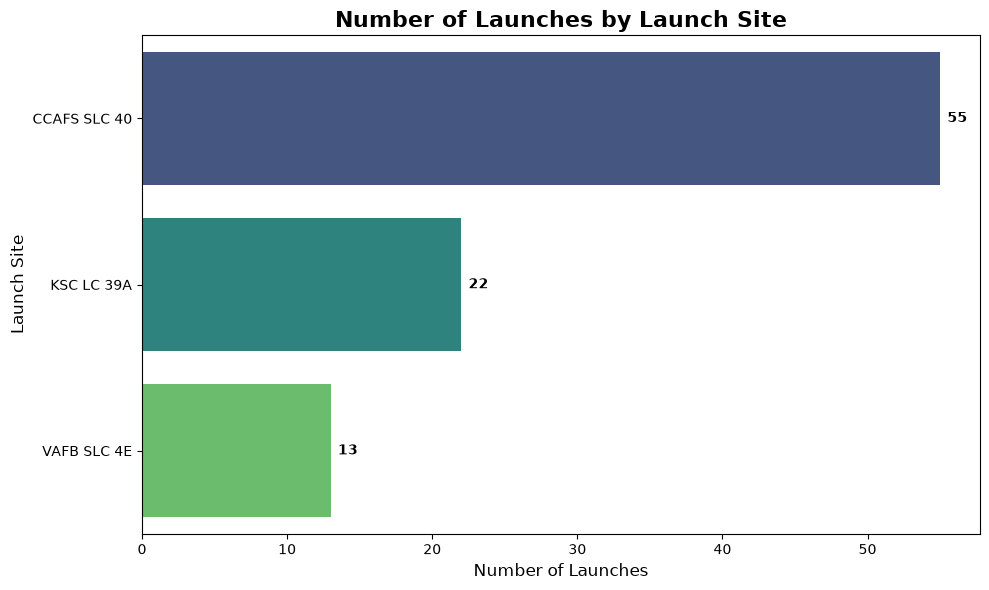

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the launch counts
launch_counts = df['LaunchSite'].value_counts()

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(y=launch_counts.index, x=launch_counts.values, palette='viridis')

# Customize the chart
plt.title('Number of Launches by Launch Site', fontsize=16, fontweight='bold')
plt.xlabel('Number of Launches', fontsize=12)
plt.ylabel('Launch Site', fontsize=12)

# Add value labels on the bars
for i, v in enumerate(launch_counts.values):
    plt.text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Each launch aims to an dedicated orbit, and here are some common orbit types:




* <b>LEO</b>: Low Earth orbit (LEO)is an Earth-centred orbit with an altitude of 2,000 km (1,200 mi) or less (approximately one-third of the radius of Earth),[1] or with at least 11.25 periods per day (an orbital period of 128 minutes or less) and an eccentricity less than 0.25.[2] Most of the manmade objects in outer space are in LEO <a href='https://en.wikipedia.org/wiki/Low_Earth_orbit'>[1]</a>.

* <b>VLEO</b>: Very Low Earth Orbits (VLEO) can be defined as the orbits with a mean altitude below 450 km. Operating in these orbits can provide a number of benefits to Earth observation spacecraft as the spacecraft operates closer to the observation<a href='https://www.researchgate.net/publication/271499606_Very_Low_Earth_Orbit_mission_concepts_for_Earth_Observation_Benefits_and_challenges'>[2]</a>.


* <b>GTO</b>(Geostationary Transfer Orbit): A geostationary transfer orbit is an elliptical Earth orbit used to transfer satellites from low Earth orbit (LEO) to geostationary orbit (GEO). In a GTO, the perigee (closest point to Earth) is much lower than GEO altitude, while the apogee (farthest point) reaches approximately 22,236 miles (35,786 kilometers) above Earth’s equator — the altitude of a geostationary orbit. Satellites in GTO use onboard propulsion to circularize their orbit at GEO altitude, where they can provide services such as weather monitoring, communications, and surveillance. <a  href="https://www.space.com/29222-geosynchronous-orbit.html" >[3] </a>.


* <b>SSO (or SO)</b>: It is a Sun-synchronous orbit  also called a heliosynchronous orbit is a nearly polar orbit around a planet, in which the satellite passes over any given point of the planet's surface at the same local mean solar time <a href="https://en.wikipedia.org/wiki/Sun-synchronous_orbit">[4] <a>.
    
    
    
* <b>ES-L1 </b>:At the Lagrange points the gravitational forces of the two large bodies cancel out in such a way that a small object placed in orbit there is in equilibrium relative to the center of mass of the large bodies. L1 is one such point between the sun and the earth <a href="https://en.wikipedia.org/wiki/Lagrange_point#L1_point">[5]</a> .
    
    
* <b>HEO</b> A highly elliptical orbit, is an elliptic orbit with high eccentricity, usually referring to one around Earth <a href="https://en.wikipedia.org/wiki/Highly_elliptical_orbit">[6]</a>.


* <b> ISS </b> A modular space station (habitable artificial satellite) in low Earth orbit. It is a multinational collaborative project between five participating space agencies: NASA (United States), Roscosmos (Russia), JAXA (Japan), ESA (Europe), and CSA (Canada)<a href="https://en.wikipedia.org/wiki/International_Space_Station"> [7] </a>


* <b> MEO </b> Geocentric orbits ranging in altitude from 2,000 km (1,200 mi) to just below geosynchronous orbit at 35,786 kilometers (22,236 mi). Also known as an intermediate circular orbit. These are "most commonly at 20,200 kilometers (12,600 mi), or 20,650 kilometers (12,830 mi), with an orbital period of 12 hours <a href="https://en.wikipedia.org/wiki/List_of_orbits"> [8] </a>


* <b> HEO </b> Geocentric orbits above the altitude of geosynchronous orbit (35,786 km or 22,236 mi) <a href="https://en.wikipedia.org/wiki/List_of_orbits"> [9] </a>


* <b> GEO </b> It is a circular geosynchronous orbit 35,786 kilometres (22,236 miles) above Earth's equator and following the direction of Earth's rotation <a href="https://en.wikipedia.org/wiki/Geostationary_orbit"> [10] </a>


* <b> PO </b> It is one type of satellites in which a satellite passes above or nearly above both poles of the body being orbited (usually a planet such as the Earth <a href="https://en.wikipedia.org/wiki/Polar_orbit"> [11] </a>

some are shown in the following plot:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/Orbits.png)


### TASK 2: Calculate the number and occurrence of each orbit


 Use the method  <code>.value_counts()</code> to determine the number and occurrence of each orbit in the  column <code>Orbit</code>


Note: Do not count GTO, as it is a transfer orbit and not itself geostationary.


In [13]:
# Apply value_counts on Orbit column
df['Orbit'].value_counts()

Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
ES-L1     1
HEO       1
SO        1
GEO       1
Name: count, dtype: int64

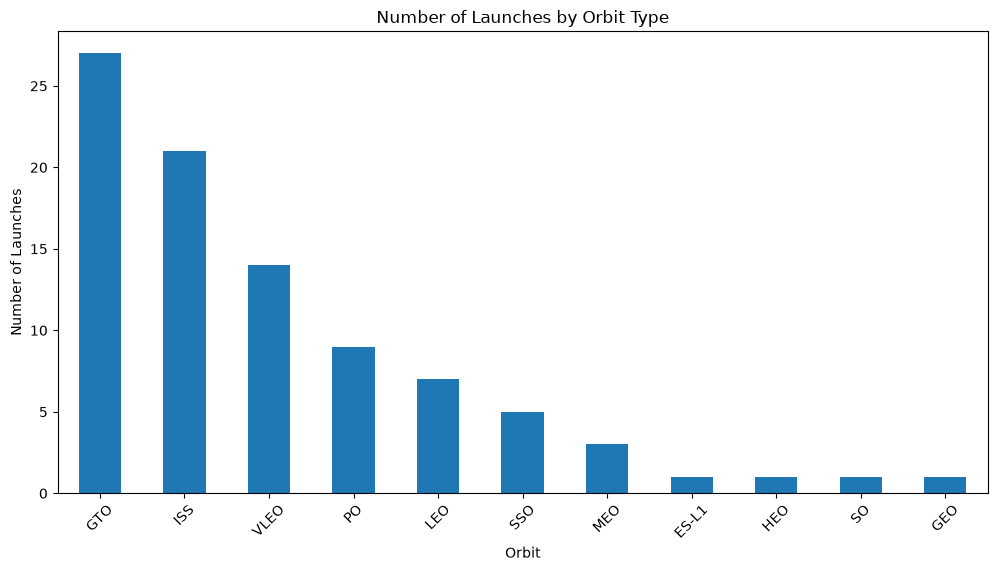

In [15]:
# Plot orbit counts (excluding GTO if you want)
orbit_counts = df['Orbit'].value_counts()

# If you want to exclude GTO as mentioned:
# orbit_counts = df[df['Orbit'] != 'GTO']['Orbit'].value_counts()

orbit_counts.plot(kind='bar', figsize=(12, 6))
plt.title('Number of Launches by Orbit Type')
plt.xlabel('Orbit')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45)
plt.show()

In [14]:
# With percentages
orbit_counts = df['Orbit'].value_counts()
orbit_percentages = df['Orbit'].value_counts(normalize=True) * 100

# Combine into a DataFrame
orbit_summary = pd.DataFrame({
    'Count': orbit_counts,
    'Percentage': orbit_percentages
})
print(orbit_summary)

       Count  Percentage
Orbit                   
GTO       27   30.000000
ISS       21   23.333333
VLEO      14   15.555556
PO         9   10.000000
LEO        7    7.777778
SSO        5    5.555556
MEO        3    3.333333
ES-L1      1    1.111111
HEO        1    1.111111
SO         1    1.111111
GEO        1    1.111111


In [15]:
# Exclude GTO
df[df['Orbit'] != 'GTO']['Orbit'].value_counts()

Orbit
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
ES-L1     1
HEO       1
SO        1
GEO       1
Name: count, dtype: int64

### TASK 3: Calculate the number and occurence of mission outcome of the orbits


Use the method <code>.value_counts()</code> on the column <code>Outcome</code> to determine the number of <code>landing_outcomes</code>.Then assign it to a variable landing_outcomes.


In [16]:
# Calculate the number and occurrence of mission outcomes
landing_outcomes = df['Outcome'].value_counts()

# Display the results
print("Landing Outcomes:")
print(landing_outcomes)

Landing Outcomes:
Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64


/tmp/ipykernel_301/1608826879.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=landing_outcomes.index, y=landing_outcomes.values, palette='viridis')


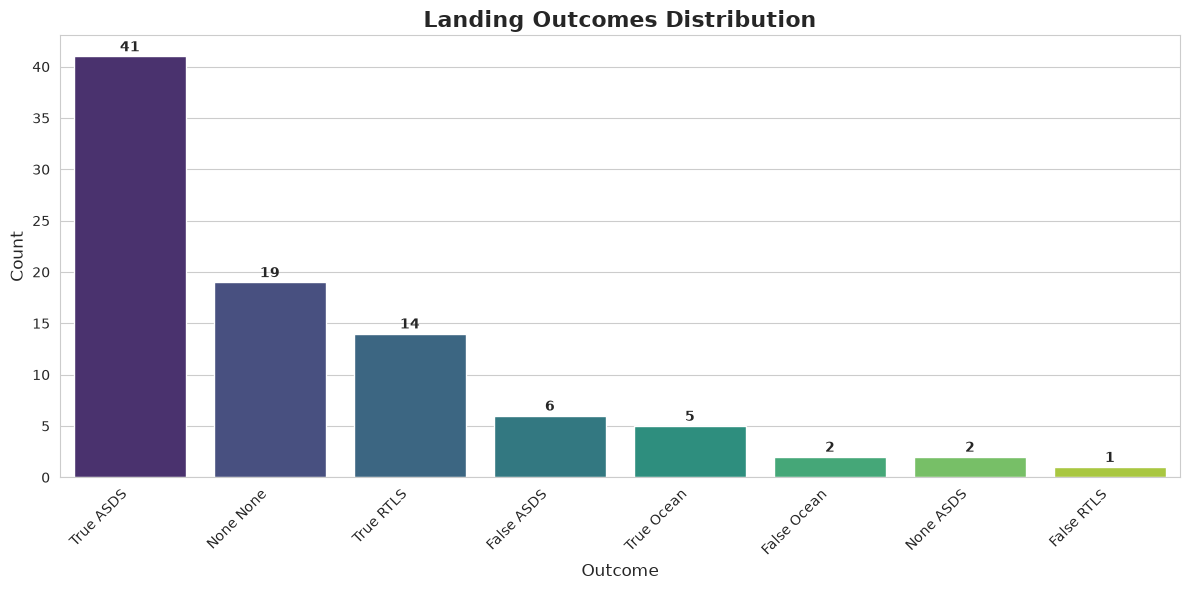

In [16]:
# Calculate landing outcomes
landing_outcomes = df['Outcome'].value_counts()

# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(12, 6))

# Bar plot with seaborn
sns.barplot(x=landing_outcomes.index, y=landing_outcomes.values, palette='viridis')

# Customize
plt.title('Landing Outcomes Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for i, v in enumerate(landing_outcomes.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

<code>True Ocean</code> means the mission outcome was successfully  landed to a specific region of the ocean while <code>False Ocean</code> means the mission outcome was unsuccessfully landed to a specific region of the ocean. <code>True RTLS</code> means the mission outcome was successfully  landed to a ground pad <code>False RTLS</code> means the mission outcome was unsuccessfully landed to a ground pad.<code>True ASDS</code> means the mission outcome was successfully  landed to a drone ship <code>False ASDS</code> means the mission outcome was unsuccessfully landed to a drone ship. <code>None ASDS</code> and <code>None None</code> these represent a failure to land.


In [17]:
for i,outcome in enumerate(landing_outcomes.keys()):
    print(i,outcome)

0 True ASDS
1 None None
2 True RTLS
3 False ASDS
4 True Ocean
5 False Ocean
6 None ASDS
7 False RTLS


We create a set of outcomes where the second stage did not land successfully:


In [18]:
bad_outcomes=set(landing_outcomes.keys()[[1,3,5,6,7]])
bad_outcomes

{'False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None'}

In [19]:
df.head(1)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0003,-80.577366,28.561857


### TASK 4: Create a landing outcome label from Outcome column


Using the <code>Outcome</code>,  create a list where the element is zero if the corresponding  row  in  <code>Outcome</code> is in the set <code>bad_outcome</code>; otherwise, it's one. Then assign it to the variable <code>landing_class</code>:


In [20]:
# Create a landing outcome label (0 = failure, 1 = success)
landing_class = [0 if outcome in bad_outcomes else 1 for outcome in df['Outcome']]

# Add as a new column to the dataframe (optional)
df['LandingClass'] = landing_class

# Check the results
print("LandingClass distribution:")
print(df['LandingClass'].value_counts())
print(f"\nSuccess rate: {df['LandingClass'].mean() * 100:.2f}%")

LandingClass distribution:
LandingClass
1    60
0    30
Name: count, dtype: int64

Success rate: 66.67%


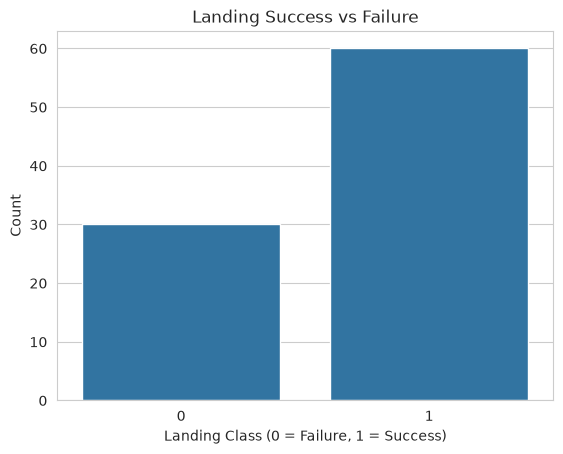

Distribution:
LandingClass
1    60
0    30
Name: count, dtype: int64

Success rate: 66.67%


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define bad outcomes (failures)
bad_outcomes = ['False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None']

# Create landing_class list (0 = failure, 1 = success)
landing_class = [0 if outcome in bad_outcomes else 1 for outcome in df['Outcome']]

# Add as new column
df['LandingClass'] = landing_class

# Now plot
sns.countplot(x='LandingClass', data=df)
plt.title('Landing Success vs Failure')
plt.xlabel('Landing Class (0 = Failure, 1 = Success)')
plt.ylabel('Count')
plt.show()

# Print distribution
print("Distribution:")
print(df['LandingClass'].value_counts())
print(f"\nSuccess rate: {df['LandingClass'].mean() * 100:.2f}%")

Code to Generate Flight Number vs Launch Site Scatter Plot

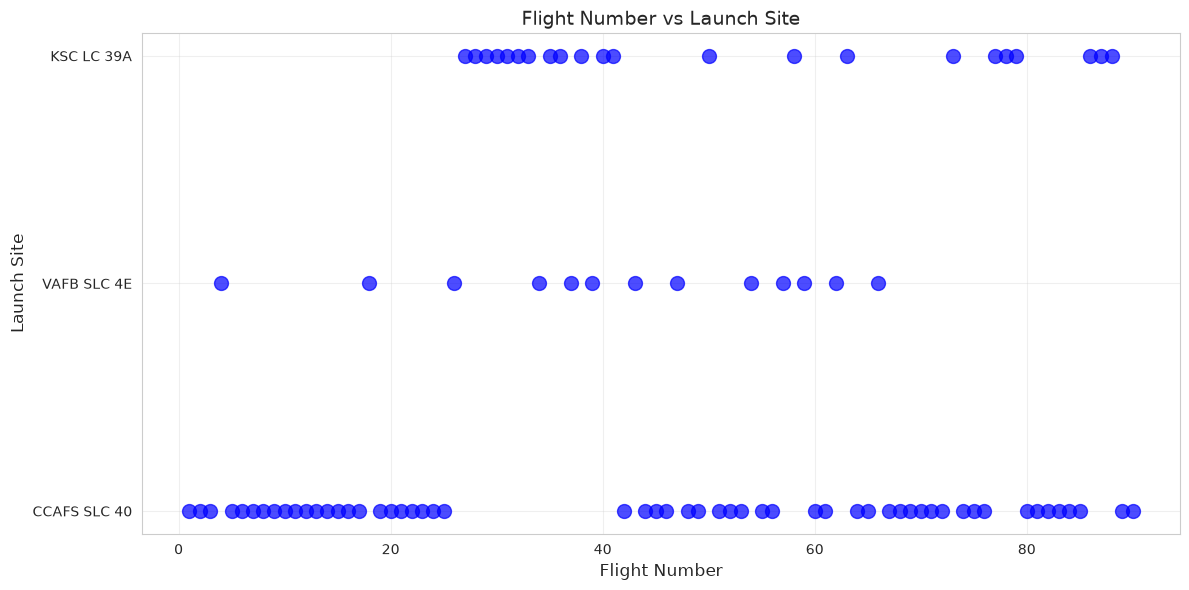

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Load your data (if not already loaded)
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Create scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(df['FlightNumber'], df['LaunchSite'], alpha=0.7, c='blue', s=100)

# Customize the chart
plt.xlabel('Flight Number', fontsize=12)
plt.ylabel('Launch Site', fontsize=12)
plt.title('Flight Number vs Launch Site', fontsize=14)
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

Code to Generate Payload vs Launch Site Scatter Plot

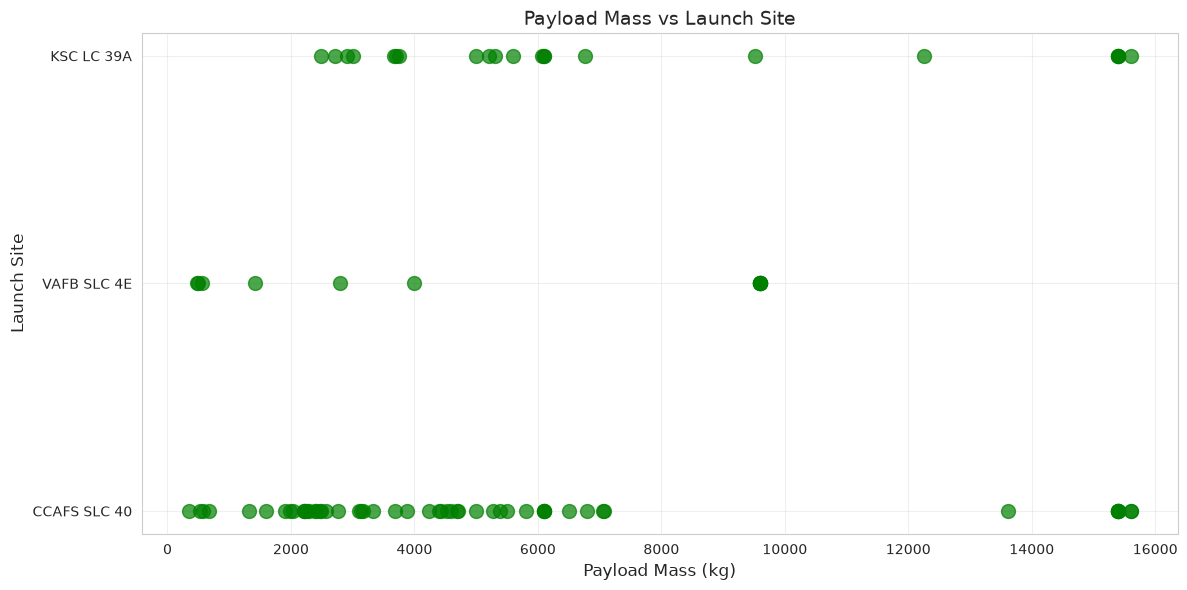

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Create scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(df['PayloadMass'], df['LaunchSite'], alpha=0.7, c='green', s=100)

# Customize
plt.xlabel('Payload Mass (kg)', fontsize=12)
plt.ylabel('Launch Site', fontsize=12)
plt.title('Payload Mass vs Launch Site', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 Success Rate vs Orbit Type Bar Chart

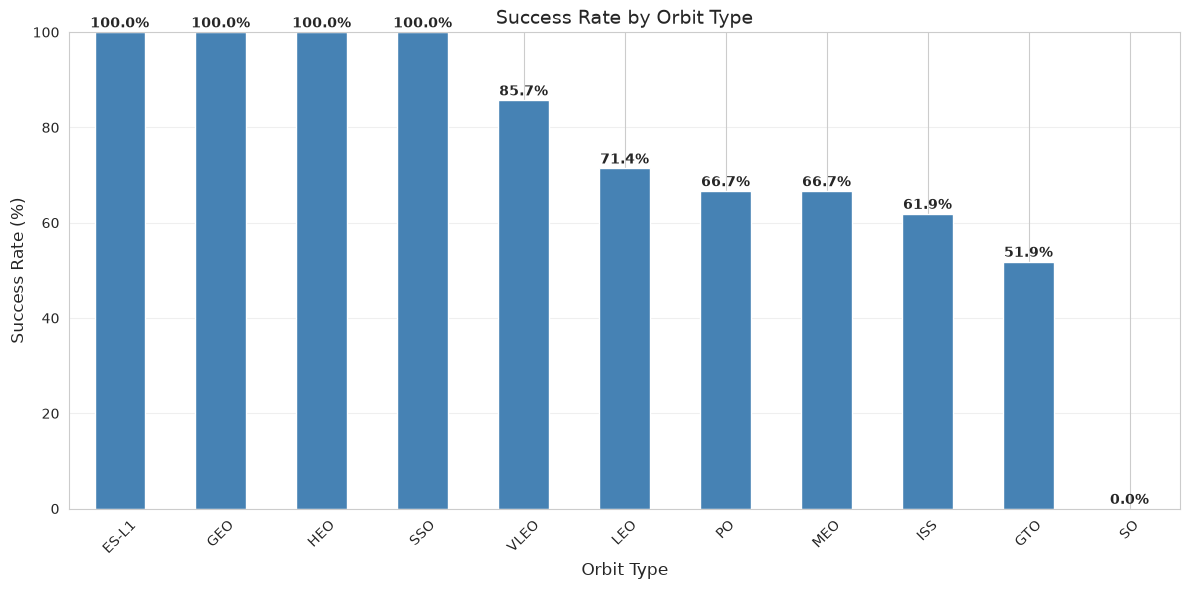

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Calculate success rate per orbit type
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False) * 100

# Create bar chart
plt.figure(figsize=(12, 6))
orbit_success.plot(kind='bar', color='steelblue')

# Customize
plt.xlabel('Orbit Type', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.title('Success Rate by Orbit Type', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(orbit_success):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Flight Number vs Orbit Type Scatter Plot

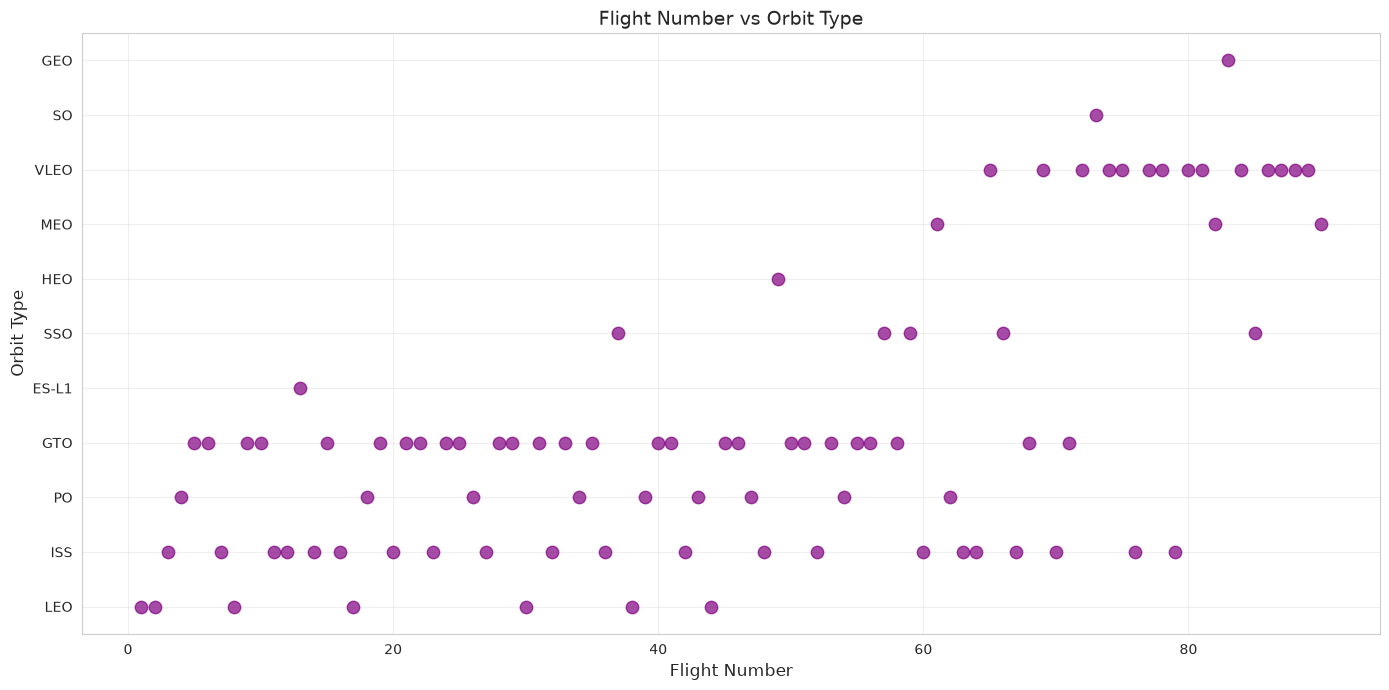

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Create scatter plot
plt.figure(figsize=(14, 7))
plt.scatter(df['FlightNumber'], df['Orbit'], alpha=0.7, c='purple', s=80)

# Customize
plt.xlabel('Flight Number', fontsize=12)
plt.ylabel('Orbit Type', fontsize=12)
plt.title('Flight Number vs Orbit Type', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Payload vs Orbit Type Scatter Plot

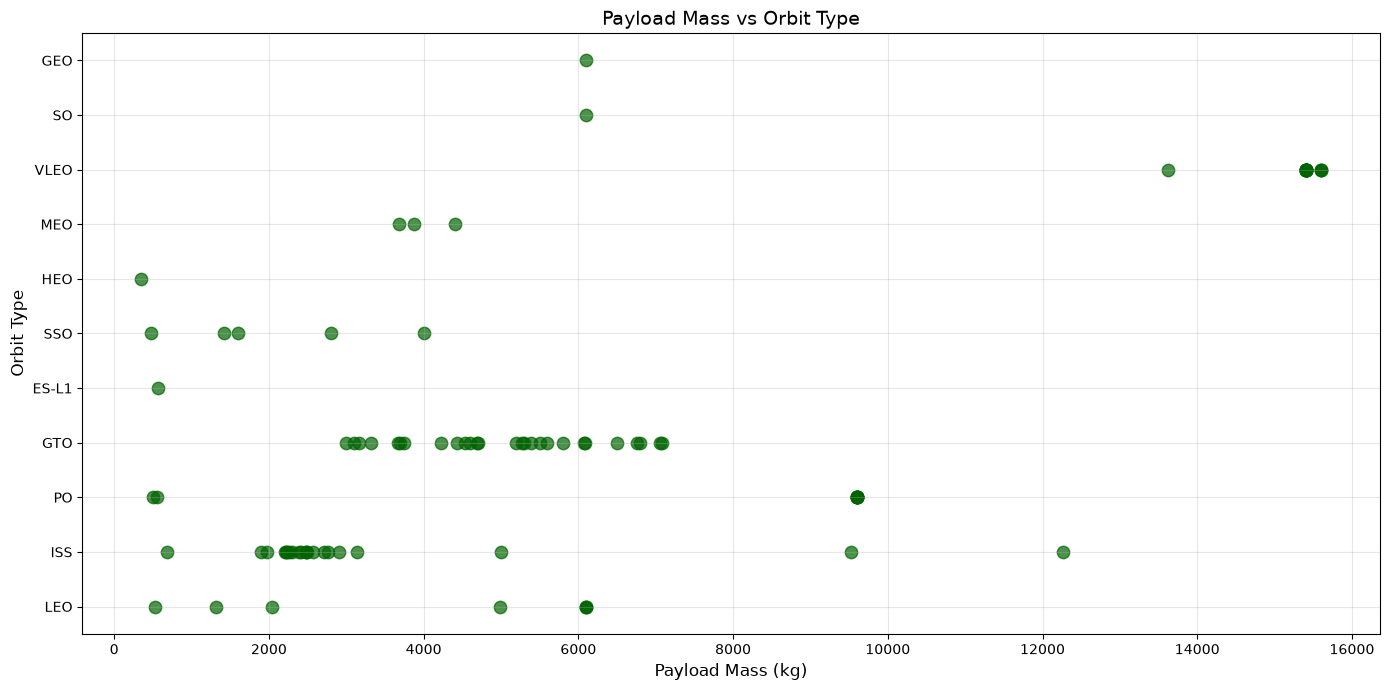

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Create scatter plot
plt.figure(figsize=(14, 7))
plt.scatter(df['PayloadMass'], df['Orbit'], alpha=0.7, c='darkgreen', s=80)

# Customize
plt.xlabel('Payload Mass (kg)', fontsize=12)
plt.ylabel('Orbit Type', fontsize=12)
plt.title('Payload Mass vs Orbit Type', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

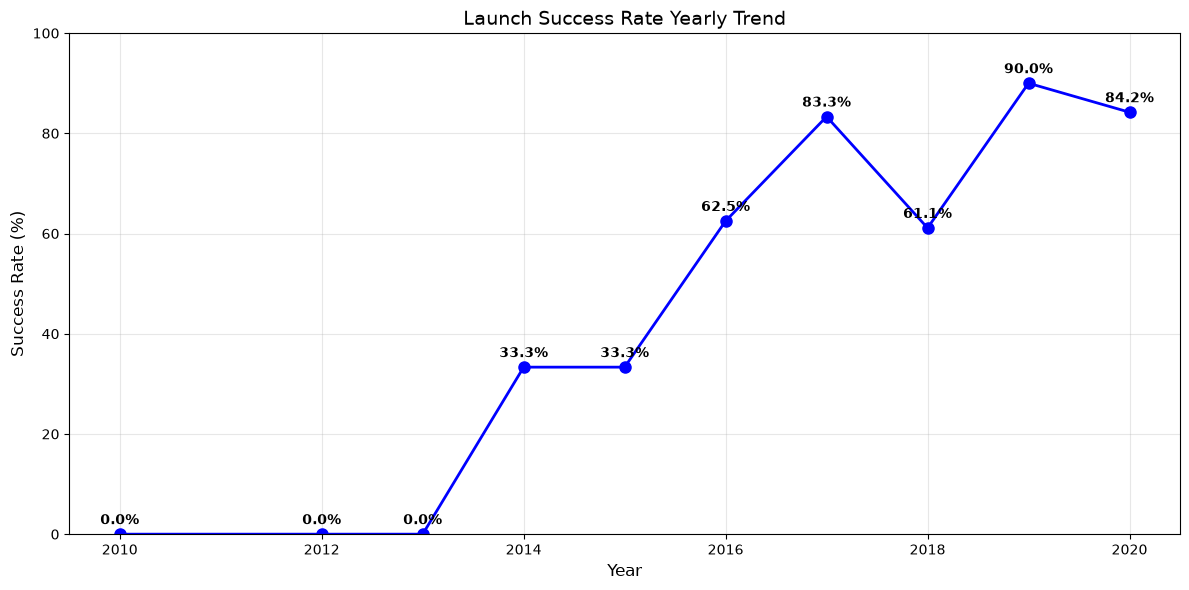

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Convert Date to datetime and extract year
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Calculate success rate per year
yearly_success = df.groupby('Year')['Class'].mean() * 100

# Create line chart
plt.figure(figsize=(12, 6))
plt.plot(yearly_success.index, yearly_success.values, marker='o', linewidth=2, markersize=8, color='blue')

# Customize
plt.xlabel('Year', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.title('Launch Success Rate Yearly Trend', fontsize=14)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)

# Add value labels on points
for x, y in zip(yearly_success.index, yearly_success.values):
    plt.text(x, y + 2, f'{y:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
df.head(1)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,LandingClass
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0003,-80.577366,28.561857,0


This variable will represent the classification variable that represents the outcome of each launch. If the value is zero, the  first stage did not land successfully; one means  the first stage landed Successfully 


In [22]:
df['Class']=landing_class
df[['Class']].head(8)

,Class
0,0
1,0
2,0
3,0
4,0
5,0
6,1
7,1


In [23]:
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,LandingClass,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0003,-80.577366,28.561857,0,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0005,-80.577366,28.561857,0,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B0007,-80.577366,28.561857,0,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B1003,-120.610829,34.632093,0,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,5e9e3032383ecb6bb234e7ca,1.0,0,B1004,-80.577366,28.561857,0,0


In [24]:
# Show a successful landing (LandingClass = 1)
df[df['LandingClass'] == 1].head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,LandingClass,Class
6,7,2014-04-18,Falcon 9,2296.0,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,5e9e3032383ecb6bb234e7ca,1.0,0,B1006,-80.577366,28.561857,1,1
7,8,2014-07-14,Falcon 9,1316.0,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,5e9e3032383ecb6bb234e7ca,1.0,0,B1007,-80.577366,28.561857,1,1
12,13,2015-02-11,Falcon 9,570.0,ES-L1,CCAFS SLC 40,True Ocean,1,True,False,True,5e9e3032383ecb6bb234e7ca,1.0,0,B1013,-80.577366,28.561857,1,1
16,17,2015-12-22,Falcon 9,2034.0,LEO,CCAFS SLC 40,True RTLS,1,True,False,True,5e9e3032383ecb267a34e7c7,1.0,0,B1019,-80.577366,28.561857,1,1
19,20,2016-04-08,Falcon 9,3136.0,ISS,CCAFS SLC 40,True ASDS,1,True,False,True,5e9e3032383ecb6bb234e7ca,2.0,1,B1021,-80.577366,28.561857,1,1


We can use the following line of code to determine  the success rate:


In [25]:
df["Class"].mean()

np.float64(0.6666666666666666)

We can now export it to a CSV for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


<code>df.to_csv("dataset_part_2.csv", index=False)</code>


## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> is a Data Scientist at IBM and pursuing a Master of Management in Artificial intelligence degree at Queen's University.


<!--
## Change Log
-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-08-31        | 1.1     | Lakshmi Holla    | Changed Markdown |
| 2020-09-20        | 1.0     | Joseph     | Modified Multiple Areas |
| 2020-11-04        | 1.1.    | Nayef      | updating the input data |
| 2021-05-026       | 1.1.    | Joseph      | updating the input data |
-->


Copyright © 2021 IBM Corporation. All rights reserved.
